<a href="https://colab.research.google.com/github/esalinasbio/taller-modelado-biomolecular/blob/master/notebooks/03_Docking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 2 - Acoplamiento molecular (*docking*)

**Taller de Modelado Biomolecular**

---

## La idea de este notebook: **redocking**

Podríamos acoplar cualquier ligando a una proteína cualquiera, obtener una pose y no tener forma de saber si es correcta. El programa siempre devuelve algo.

En vez de eso vamos a hacer **redocking**: tomamos una estructura cristalográfica donde la posición del ligando **ya se conoce experimentalmente**, le quitamos el ligando, lo acoplamos de vuelta, y medimos qué tan lejos quedó de la conformación real.

Eso nos da una **referencia**.

> Convención: **RMSD < 2 Å** respecto a la pose cristalográfica se considera
> un acierto..

---

El *notebook* está escrito con funciones parametrizadas. Pueden cambiar el PDB y el código del ligando y correrlo con su propio sistema.

In [ ]:
#@title Instalar `condacolab` y `python` 3.12
#@markdown Se va a reiniciar la sesión, no pasa nada
!pip install -q "https://github.com/conda-incubator/condacolab/archive/main.zip"
import condacolab
# Use Python 3.12
condacolab.install(python_version="3.12")

In [ ]:
#@title Instalar dependencias
import sys, subprocess, time

_t0 = time.time()

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

pip_install("numpy")
pip_install("rdkit")
pip_install("vina")
pip_install("meeko")
pip_install("gemmi")
pip_install("openbabel")
pip_install("py3Dmol")
pip_install("scipy")
pip_install("plip")
pip_install("prolif")

print(f"Instalación completada en {time.time() - _t0:.1f} s")

import os, urllib.request
import numpy as np, py3Dmol
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, rdMolAlign, Draw, Descriptors
RDLogger.DisableLog("rdApp.*")
from vina import Vina
from meeko import MoleculePreparation, PDBQTWriterLegacy, PDBQTMolecule, RDKitMolCreate
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
C_REC, C_XTAL, C_DOCK, GRIS = "#2E8B8B", "#E8813A", "#7c3aed", "#64748b"
print(f"Listo en {time.time()-_t0:.0f}s")

def descargar(pdb_id):
    f = f"{pdb_id.upper()}.pdb"
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_id.upper()}.pdb", f)
    return f

def separar(pdb_id, cod_ligando, cadena=None, conservar_aguas=False):
    # Divide el PDB en receptor y ligando cristalografico.
    rec, lig = [], []
    for l in open(descargar(pdb_id)):
        if l.startswith("ENDMDL"): break
        if not l.startswith(("ATOM", "HETATM")): continue
        resn, ch = l[17:20].strip(), l[21]
        if cadena is not None and ch != cadena:
            continue
        if resn == cod_ligando:
            lig.append(l)
        elif resn in ("HOH", "WAT"):
            if conservar_aguas: rec.append(l)
        elif l.startswith("ATOM"):
            rec.append(l)
    open("receptor.pdb", "w").write("".join(rec) + "END\n")
    open("ligando_xtal.pdb", "w").write("".join(lig) + "END\n")
    return len(rec), len(lig)

def ligando_de_referencia(cod_ligando):
    # Reconstruye el ligando con ordenes de enlace correctos, usando la
    # definicion quimica del PDB como plantilla.
    f = f"{cod_ligando}_ideal.sdf"
    if not os.path.exists(f):
        urllib.request.urlretrieve(
            f"https://files.rcsb.org/ligands/download/{cod_ligando}_ideal.sdf", f)
    plantilla = Chem.MolFromMolFile(f)
    crudo = Chem.MolFromPDBBlock(open("ligando_xtal.pdb").read(), removeHs=True)
    xtal = AllChem.AssignBondOrdersFromTemplate(plantilla, crudo)
    return xtal, Chem.MolToSmiles(plantilla)

def preparar_receptor(pdb="receptor.pdb", salida="receptor.pdbqt"):
    !obabel {pdb} -O {salida} -xr 2>/dev/null
    n = sum(1 for l in open(salida) if l.startswith("ATOM"))
    return salida, n

def preparar_ligando(smiles, semilla=0xC0FFEE, salida="ligando.pdbqt"):
    # Conformero NUEVO desde SMILES
    m = Chem.AddHs(Chem.MolFromSmiles(smiles))
    AllChem.EmbedMolecule(m, randomSeed=semilla)
    AllChem.MMFFOptimizeMolecule(m)
    setup = MoleculePreparation().prepare(m)[0]
    txt, ok, err = PDBQTWriterLegacy.write_string(setup)
    if not ok: raise RuntimeError(err)
    open(salida, "w").write(txt)
    n_tors = sum(1 for l in txt.split("\n") if l.startswith("BRANCH"))
    return salida, m, n_tors

def caja_desde(mol, margen=5.0):
    p = mol.GetConformer().GetPositions()
    centro = p.mean(axis=0)
    tam = (p.max(axis=0) - p.min(axis=0)) + 2*margen
    return centro, np.maximum(tam, 16.0)

def caja_de_todo(pdb="receptor.pdb", margen=4.0):
    p = np.array([[float(l[30+8*i:38+8*i]) for i in range(3)]
                  for l in open(pdb) if l.startswith("ATOM")])
    return p.mean(axis=0), (p.max(axis=0) - p.min(axis=0)) + 2*margen

def acoplar(rec, lig, centro, tam, exhaustividad=8, semilla=42, n_poses=9,
            salida="poses.pdbqt", funcion="vina"):
    v = Vina(sf_name=funcion, seed=semilla, verbosity=0)
    v.set_receptor(rec); v.set_ligand_from_file(lig)
    v.compute_vina_maps(center=[float(x) for x in centro],
                        box_size=[float(x) for x in tam])
    t0 = time.time(); v.dock(exhaustiveness=exhaustividad, n_poses=n_poses, min_rmsd=0.5)
    v.write_poses(salida, n_poses=n_poses, overwrite=True)
    return salida, np.array(v.energies(n_poses=n_poses))[:, 0], time.time()-t0

def evaluar(poses_pdbqt, xtal):
    # RMSD de cada pose contra la cristalografica, corregido por simetria.
    pm = PDBQTMolecule.from_file(poses_pdbqt, skip_typing=True)
    dk = Chem.RemoveHs(RDKitMolCreate.from_pdbqt_mol(pm)[0])
    xn = Chem.RemoveHs(xtal)
    out = []
    for i in range(dk.GetNumConformers()):
        s = Chem.Mol(dk); s.RemoveAllConformers()
        s.AddConformer(dk.GetConformer(i), assignId=True)
        out.append(rdMolAlign.CalcRMS(s, xn))
    return np.array(out), dk

def tabla(energias, rmsds, titulo=""):
    print(f"\n{titulo}")
    print(f"{'pose':>5}{'afinidad (kcal/mol)':>22}{'RMSD (Å)':>12}{'':>4}")
    print("-"*45)
    for i, (e, r) in enumerate(zip(energias, rmsds), 1):
        marca = "  <-- acierto" if r < 2.0 else ""
        print(f"{i:>5}{e:>22.2f}{r:>12.2f}{marca}")
    print(f"\nMejor RMSD obtenido: {rmsds.min():.2f} Å "
          f"(pose {int(np.argmin(rmsds))+1} de {len(rmsds)})")
    return rmsds.min()

def ver_caja(centro, tam, pdb="receptor.pdb", extra=None):
    v = py3Dmol.view(width=760, height=430)
    v.addModel(open(pdb).read(), "pdb")
    v.setStyle({}, {"cartoon": {"color": C_REC}})
    if extra:
        v.addModel(open(extra).read(), "pdb", {"keepH": True})
        v.setStyle({"model": 1}, {"stick": {"radius": 0.2, "colorscheme": "orangeCarbon"}})
    v.addBox({"center": {"x": float(centro[0]), "y": float(centro[1]), "z": float(centro[2])},
              "dimensions": {"w": float(tam[0]), "h": float(tam[1]), "d": float(tam[2])},
              "color": "magenta", "opacity": 0.65})
    v.zoomTo(); v.show()

def ver_poses(dk, xtal, n=3, pdb="receptor.pdb"):
    v = py3Dmol.view(width=780, height=460)
    v.addModel(open(pdb).read(), "pdb")
    v.setStyle({}, {"cartoon": {"color": "#cbd5e1", "opacity": 0.55}})
    v.addModel(Chem.MolToMolBlock(xtal), "mol")
    v.setStyle({"model": 1}, {"stick": {"radius": 0.22, "colorscheme": "orangeCarbon"}})
    for i in range(min(n, dk.GetNumConformers())):
        v.addModel(Chem.MolToMolBlock(dk, confId=i), "mol")
        v.setStyle({"model": 2+i}, {"stick": {"radius": 0.14, "colorscheme":
                    ["purpleCarbon", "cyanCarbon", "greenCarbon"][i % 3]}})
    v.zoomTo(); v.show()
    print("Naranja = pose CRISTALOGRÁFICA (la verdad) · colores = poses acopladas")

print("Funciones cargadas.")

---
# Parte A - Proteína y fármaco

Sistema por defecto: **1IEP**, el dominio kinasa de c-Abl unido con el inhibidor imatinib (código `STI`), que se utiliza como tratamiento para la leucemia mieloide.





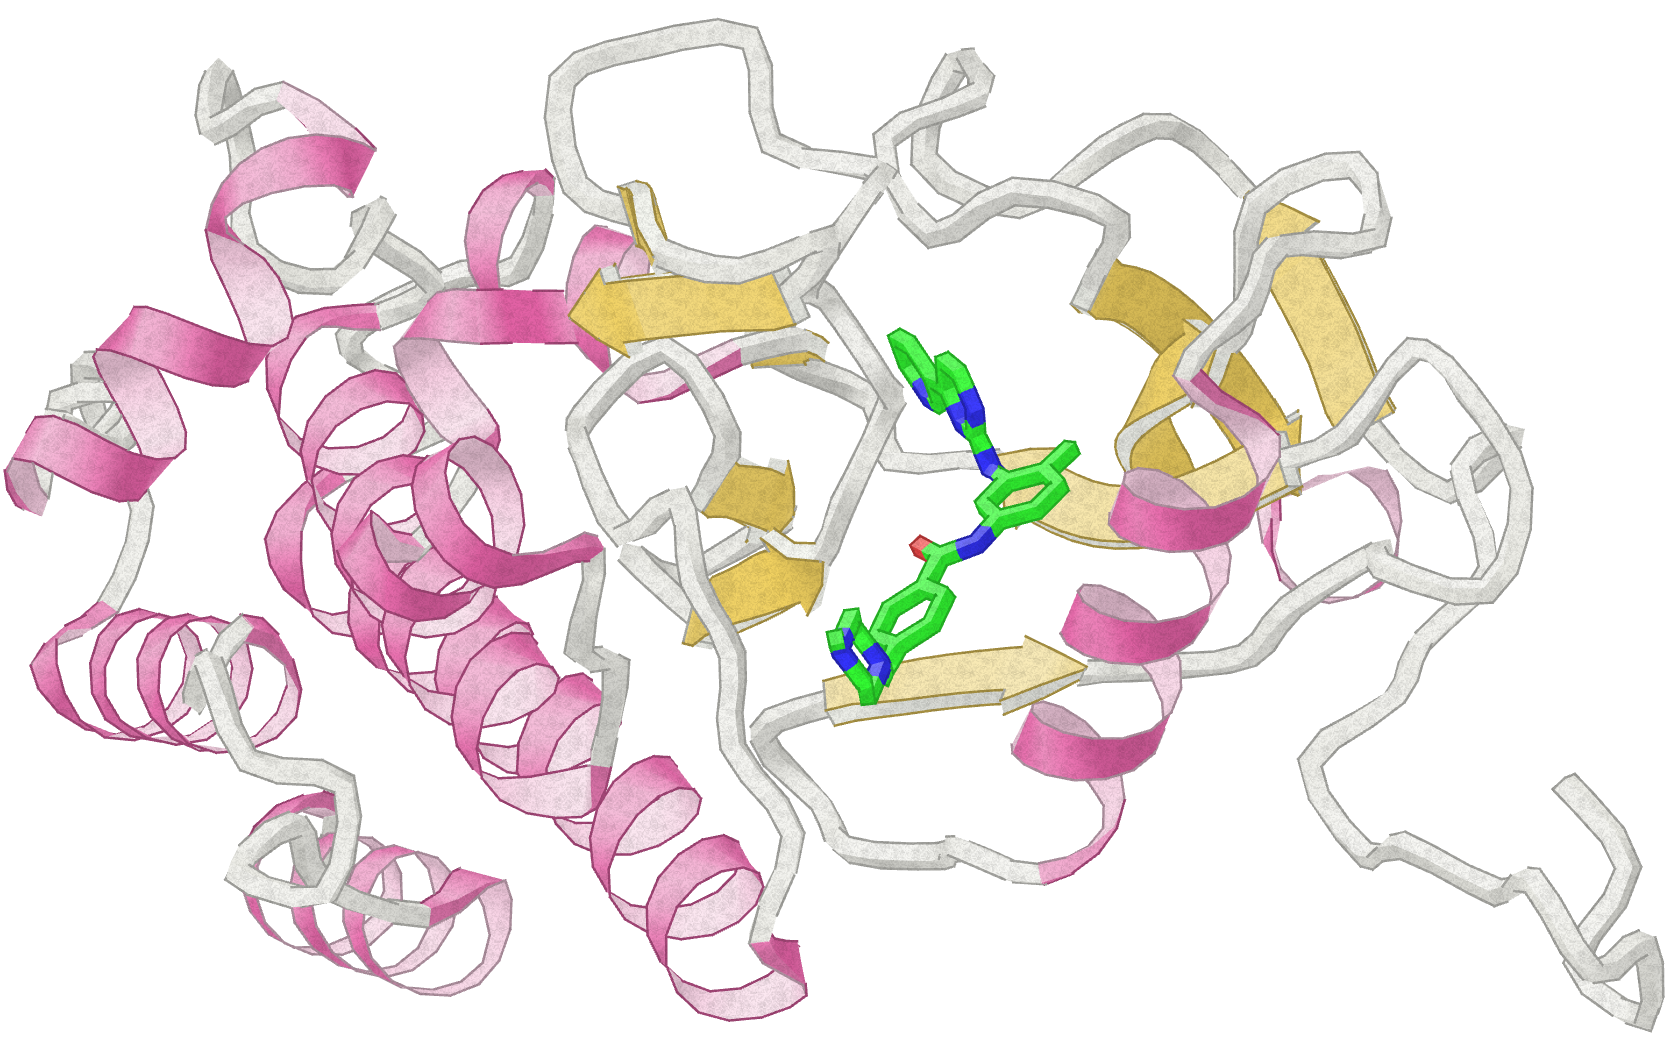

Si quieren otro sistema, cambien los campos. Sólo necesitan un PDB con un ligando cristalizado y su código de tres letras.

> ### Pregunta
> El ligando tiene decenas de átomos y varios enlaces rotables. El pocket es grande.
> **¿Cuántas conformaciones distintas creen que hay que explorar? ¿Y cuántas
> explorará el programa realmente?**

In [ ]:
#@title A1 - Descargar y separar receptor de ligando
PDB_ID      = "1IEP"   #@param {type:"string"}
COD_LIGANDO = "STI"    #@param {type:"string"}
CADENA      = "A"      #@param {type:"string"}
CONSERVAR_AGUAS = False #@param {type:"boolean"}

n_rec, n_lig = separar(PDB_ID, COD_LIGANDO, CADENA or None, CONSERVAR_AGUAS)
xtal, smiles = ligando_de_referencia(COD_LIGANDO)
xtal_flat, smiles = ligando_de_referencia(COD_LIGANDO)

print("="*60)
print(f"  Átomos del receptor          : {n_rec}")
print(f"  Átomos del ligando (cristal) : {n_lig}")
print(f"  Aguas conservadas            : {'sí' if CONSERVAR_AGUAS else 'no'}")
print(f"  SMILES del ligando           : {smiles}")
print(f"  Enlaces rotables             : "
      f"{Chem.rdMolDescriptors.CalcNumRotatableBonds(xtal)}")
print(f"  Peso molecular               : "
      f"{Chem.Descriptors.MolWt(xtal):.1f} Da")
print("="*60)
AllChem.Compute2DCoords(xtal_flat)

print("Ligando:")
Draw.MolToImage(Chem.RemoveHs(xtal_flat), size=(420, 260))

In [ ]:
#@title A2 - Ver dónde está realmente el ligando

SURFACE = False # @param {"type":"boolean","placeholder":"True"}
SURF_OPACITY = 0.65 # @param {"type":"slider","min":0,"max":1,"step":0.01}

with open("receptor.pdb") as f:
    protein_pdb = f.read()

with open("/content/ligando_xtal.pdb") as f:
    ligand_pdb = f.read()

view = py3Dmol.view(width=900, height=700)

view.addModel(protein_pdb, "pdb")
view.setStyle({"model": 0, "chain": "A"}, {"cartoon": {"color": "#4C78A8"}})
view.setStyle({"model": 0, "chain": "B"}, {"cartoon": {"color": "#E45756"}})

if SURFACE:
  view.addSurface(
      py3Dmol.VDW,
      {"opacity": SURF_OPACITY, "color": "gray"},
      {"model": 0}
  )

view.addModel(ligand_pdb, "pdb")
view.setStyle(
    {"model": 1},
    {"stick": {"colorscheme": "orangeCarbon", "radius": 0.25}}
)

view.zoomTo()
view.setBackgroundColor("white")
view.show()

## La caja de búsqueda

El docking no busca en toda la proteína: busca dentro de una **caja** que nosotros definimos. Ésa es la decisión más importante del método: determina el espacio de busqueda.

Aquí la centramos en el ligando cristalográfico. **Eso es información que en un caso real no tendrían.** Lo hacemos a propósito para separar dos preguntas:

1. ¿Puede el programa reconstruir la pose *si le decimos dónde buscar*?
2. ¿Puede encontrar el sitio *por sí solo*?

### Qué hace la celda siguiente

- **La caja.** Tomamos el ligando cristalográfico, calculamos su centroide y su extensión, y añadimos `MARGEN_A` Angstoms por lado. La caja tiene que dejar espacio para que el ligando gire y se desplace, pero cada Angstrom extra multiplica el volumen a explorar.

- **El receptor.** `obabel -xr` lo convierte el PDB a PDBQT: añade los tipos de átomo de AutoDock y las cargas parciales que necesita la función de puntuación. La bandera `-xr` marca la molécula como **rígida**: el receptor no se moverá ni un Angstrom en todo el ejercicio.

- **El ligando.** Aquí está lo importante: generamos un confórmero **nuevo** desde el SMILES con `EmbedMolecule`, no partimos de la pose cristalográfica.

In [ ]:
#@title A3 - Definir la caja y preparar los archivos
MARGEN_A = 5.0   #@param {type:"number"}
SEMILLA_CONFORMERO = -1   #@param {type:"integer"}

centro, tam = caja_desde(xtal, MARGEN_A)
rec_pdbqt, n_at = preparar_receptor()
lig_pdbqt, m_nuevo, n_tors = preparar_ligando(smiles, SEMILLA_CONFORMERO)

rmsd_inicial = rdMolAlign.CalcRMS(Chem.RemoveHs(m_nuevo), Chem.RemoveHs(xtal))
print("="*58)
print(f"  Receptor PDBQT   : {n_at} átomos")
print(f"  Torsiones activas del ligando : {n_tors}")
print(f"  Caja: centro ({centro[0]:.1f}, {centro[1]:.1f}, {centro[2]:.1f}) Å")
print(f"        tamaño ({tam[0]:.1f}, {tam[1]:.1f}, {tam[2]:.1f}) Å"
      f"  ->  volumen {np.prod(tam)/1000:.1f} nm³")
print("-"*60)
print(f"  RMSD del confórmero inicial vs. cristal : {rmsd_inicial:.1f} Å")
print("="*60)

ver_caja(centro, tam, extra="ligando_xtal.pdb")

#### Ahora sí, el acoplamiento.
Vamos a utilizar `VINA` para hacer el docking. El programa va a lanzar varias búsquedas independientes desde posiciones y orientaciones al azar dentro de la caja, y cada una explorará traslaciones, rotaciones y torsiones del ligando buscando el mínimo de la función de puntuación.

`EXHAUSTIVIDAD` controla cuántas búsquedas hace. La semilla existe porque todo esto arranca de números aleatorios, y fijarla nos ayuda a reproducir los resultados. Al final nos devuelve las mejores poses oordenadas por puntuacion, y las comparamos una por una contra la estructura cristalográfica.

In [ ]:
#@title A4 - Docking
EXHAUSTIVIDAD = 8    #@param {type:"integer"}
SEMILLA       = 42   #@param {type:"integer"}
N_POSES       = 15    #@param {type:"integer"}

poses, energias, dt = acoplar(rec_pdbqt, lig_pdbqt, centro, tam,
                              EXHAUSTIVIDAD, SEMILLA, N_POSES)
rmsds, dk = evaluar(poses, xtal)
print(f"Docking terminado en {dt:.0f} s")
mejor_A = tabla(energias, rmsds, f"{PDB_ID} · caja centrada en el sitio")

In [ ]:
#@title A5 - Ver el resultado
ver_poses(dk, xtal, n=3)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(rmsds, energias, s=70, c=[C_DOCK if r >= 2 else "#16a34a" for r in rmsds],
           edgecolors="k", linewidths=0.5, zorder=3)
for i, (r, e) in enumerate(zip(rmsds, energias), 1):
    ax.annotate(str(i), (r, e), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(2.0, ls="--", c="#b91c1c", lw=1.3)
ax.text(2.1, energias.max(), "2 Å", color="#b91c1c", fontsize=9)
ax.set_xlabel("RMSD respecto a la pose cristalográfica (Å)")
ax.set_ylabel("afinidad estimada (kcal/mol)")
ax.set_title("score vs rmsd")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

print(f'''
Miren el eje vertical: entre la mejor pose y la peor hay
{abs(energias.max()-energias.min()):.1f} kcal/mol
Miren el eje horizontal: hay {rmsds.max()-rmsds.min():.0f} Å
''')

Unas pocas kcal/mol separan poses que están a más de diez ANgstroms de distancia. La función de puntuación ordena razonablemente bien DENTRO de este sistema, pero la diferencia numérica entre "perfecta" y "completamente equivocada" es pequeña.

Si el margen entre acertar y fallar es de 2-3 kcal/mol, ¿qué tanta confianza
le darían a una diferencia de 1 kcal/mol entre DOS LIGANDOS distintos?

Ésa es la razón por la que se dice que el docking predice POSES, no AFINIDADES.

### ¿La pose correcta?

Hasta aquí hemos juzgado el docking con una sola vara: la distancia geométrica a la
estructura cristalográfica. Pero un RMSD bajo no garantiza que el ligando esté haciendo
las mismas **interacciones** que hace en realidad. Y las interacciones son lo que
importa: son las que dicen qué residuo mutar, qué grupo químico modificar.

`PLIP` detecta contactos hidrofóbicos, puentes de hidrógeno, puentes salinos y
apilamiento π a partir de la geometría del complejo. Vamos a calcular la **huella de
interacciones** de la pose cristalográfica y la de la pose acoplada, y compararlas.

> ### Pregunta
> Su mejor pose está a menos de 2 Å del cristal.
> **¿Qué fracción de las interacciones esperan que reproduzca? ¿Todas?**

In [ ]:
#@title A6 - Huella de la interacción PLIP
import subprocess, re

TIPOS = {"Hydrophobic Interactions": "hidrofóbico",
         "Hydrogen Bonds": "puente de H",
         "Salt Bridges": "puente salino",
         "pi-Stacking": "apilamiento π",
         "pi-Cation Interactions": "π-catión",
         "Water Bridges": "puente de agua",
         "Halogen Bonds": "halógeno"}

def complejo_pdb(mol, salida, receptor="receptor.pdb"):
    lig = Chem.AddHs(mol, addCoords=True); conf = lig.GetConformer()
    lineas = [l for l in open(receptor) if l.startswith("ATOM")]
    for i, a in enumerate(lig.GetAtoms(), 1):
        p = conf.GetAtomPosition(i-1); e = a.GetSymbol()
        lineas.append(f"HETATM{9000+i:5d} {(e+str(i))[:4]:^4s} LIG X 900    "
                      f"{p.x:8.3f}{p.y:8.3f}{p.z:8.3f}  1.00  0.00          {e:>2s}\n")
    open(salida, "w").write("".join(lineas) + "END\n")
    return salida

def huella(pdb, nombre):
    # PLIP en subproceso: si truena, no se lleva el kernel por delante
    r = subprocess.run(["python", "-m", "plip.plipcmd", "-f", pdb, "-t",
                        "--name", nombre], capture_output=True, text=True)
    if not os.path.exists(nombre + ".txt"):
        print("PLIP falló:", r.stderr[-500:]); return set(), {}
    seccion, conjunto, cuentas = None, set(), {}
    for linea in open(nombre + ".txt"):
        m = re.match(r"\*\*(.+?)\*\*", linea.strip())
        if m:
            seccion = TIPOS.get(m.group(1)); continue
        if seccion and linea.startswith("| ") and not linea.startswith("| RESNR"):
            campos = [x.strip() for x in linea.split("|")[1:-1]]
            if campos and campos[0].isdigit():
                conjunto.add((seccion, int(campos[0]), campos[1]))
                cuentas[seccion] = cuentas.get(seccion, 0) + 1
    return conjunto, cuentas

mejor = Chem.Mol(dk); mejor.RemoveAllConformers()
mejor.AddConformer(dk.GetConformer(0), assignId=True)
h_x, c_x = huella(complejo_pdb(xtal,  "cx_xtal.pdb"),  "rep_xtal")
h_d, c_d = huella(complejo_pdb(mejor, "cx_dock.pdb"),  "rep_dock")

print(f"{'tipo':<18}{'cristal':>9}{'acoplada':>10}")
print("-"*37)
for t in sorted(set(c_x) | set(c_d)):
    print(f"{t:<18}{c_x.get(t,0):>9}{c_d.get(t,0):>10}")

comunes, perdidas, nuevas = h_x & h_d, h_x - h_d, h_d - h_x
jac = len(comunes)/len(h_x | h_d) if (h_x | h_d) else 0
print(f"\nRMSD de la pose            : {rmsds[0]:.2f} Å")
print(f"Interacciones reproducidas : {len(comunes)} de {len(h_x)}")
print(f"Índice de Jaccard          : {jac:.2f}   (1.0 = huella idéntica)")

if perdidas:
    print("\nPERDIDAS (están en el cristal, no en la pose acoplada):")
    for t, n, rt in sorted(perdidas, key=lambda x: x[1]):
        print(f"   {t:<18} {rt}{n}")
if nuevas:
    print("\nINVENTADAS (sólo en la pose acoplada):")
    for t, n, rt in sorted(nuevas, key=lambda x: x[1]):
        print(f"   {t:<18} {rt}{n}")

print('''
Un RMSD por debajo de 2 Å se considera un acierto, y sin embargo la huella de
interacciones casi nunca coincide del todo. Fíjense en QUÉ se pierde: si falta
un puente de hidrógeno con un residuo clave, la pose es geométricamente correcta
y químicamente incompleta.

Si tomaran esta pose para decidir qué residuo mutar o qué grupo añadir al
ligando, las interacciones perdidas o inventadas son exactamente donde se
equivocarían.

Y PLIP calcula esto sobre UNA estructura congelada. En la Parte 1 midieron
ocupancias a lo largo de 100 ns: unos contactos están siempre y otros aparecen
y desaparecen. Una huella estática no distingue entre esas dos cosas.
''')

In [ ]:
#@title A8 - Diagrama 2D de interacciones con ProLIF

import warnings; warnings.filterwarnings("ignore")
import prolif as plf, MDAnalysis as mda
from prolif.plotting.network import LigNetwork
from IPython.display import display, HTML

QUE_POSE = "acoplada"   #@param ["acoplada", "cristal"]

_mol = mejor if QUE_POSE == "acoplada" else xtal
_lig = plf.Molecule.from_rdkit(Chem.AddHs(_mol, addCoords=True))
_prot = plf.Molecule.from_mda(
    mda.Universe("receptor.pdb").select_atoms("protein"), NoImplicit=False)

fp = plf.Fingerprint()
fp.run_from_iterable([_lig], _prot, progress=False)
tabla_int = fp.to_dataframe().T

print(f"Pose: {QUE_POSE}  ·  interacciones detectadas: {tabla_int.shape[0]}\n")
print(tabla_int.reset_index()[["protein", "interaction"]].to_string(index=False))

net = LigNetwork.from_fingerprint(fp, _lig, kind="frame", frame=0)
net.save("red_interacciones.html")
display(HTML(open("red_interacciones.html").read()))

### Una segunda opinión

`vinardo` es otra función de puntuación empírica, incluida también en `VINA`. Fue reparametrizada a partir de los mismos términos físicos pero con otro conjunto de entrenamiento y otros pesos.

Acoplamos exactamente lo mismo con ella y comparamos.

> ### Pregunta
> **¿Esperan que dé el mismo número, un número parecido, o un número distinto?**
> ¿Y la misma pose?

In [ ]:
#@title A6 - La misma pose, otra función de puntuación
poses_vd, ener_vd, dt_vd = acoplar(rec_pdbqt, lig_pdbqt, centro, tam,
                                   EXHAUSTIVIDAD, SEMILLA, N_POSES,
                                   "poses_vinardo.pdbqt", funcion="vinardo")
rmsd_vd, dk_vd = evaluar(poses_vd, xtal)
tabla(ener_vd, rmsd_vd, f"{PDB_ID} - función VINARDO")

n = min(len(energias), len(ener_vd))
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
x = np.arange(n)
ax[0].bar(x-0.2, energias[:n], 0.4, label="vina", color=C_REC)
ax[0].bar(x+0.2, ener_vd[:n], 0.4, label="vinardo", color=C_DOCK)
ax[0].set_xticks(x); ax[0].set_xticklabels([str(i+1) for i in x])
ax[0].set_xlabel("pose"); ax[0].set_ylabel("afinidad (kcal/mol)")
ax[0].set_title("Mismo sistema, dos funciones"); ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.25, axis="y")

ax[1].scatter(rmsds, energias, s=60, color=C_REC, edgecolors="k",
              linewidths=0.4, label="vina")
ax[1].scatter(rmsd_vd, ener_vd, s=60, color=C_DOCK, edgecolors="k",
              linewidths=0.4, label="vinardo")
ax[1].axvline(2.0, ls="--", c="#b91c1c", lw=1.3)
ax[1].set_xlabel("RMSD (Å)"); ax[1].set_ylabel("afinidad (kcal/mol)")
ax[1].set_title("¿Cambia la calidad, o sólo el número?")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f'''
Mejor pose según vina    : RMSD {rmsds[0]:.2f} Å, {energias[0]:.1f} kcal/mol
Mejor pose según vinardo : RMSD {rmsd_vd[0]:.2f} Å, {ener_vd[0]:.1f} kcal/mol

Diferencia entre las dos estimaciones para poses casi idénticas:
{abs(energias[0]-ener_vd[0]):.1f} kcal/mol.
''')

Las dos son funciones razonables, publicadas y usadas. Simplemente no están
midiendo una energía libre, están calculando una puntuacion que **ordena** poses. Comparar el valor absoluto entre funciones o entre sistemas no significa nada.

Si las dos coinciden en la pose pero no en la puntuación, eso les dice exactamente en qué parte del resultado pueden confiar.

---
# Parte B — ¿De qué depende que funcione?

Acabamos de ver el mejor caso posible. Ahora tres experimentos que muestran qué pasa
cuando quitamos una de las condiciones favorables.

In [ ]:
#@title B1 - Docking ciego: sin decirle dónde buscar
EXHAUSTIVIDAD_CIEGO = 8   #@param {type:"integer"}

centro_c, tam_c = caja_de_todo()
print(f"Caja a ciegas: {tam_c[0]:.0f} x {tam_c[1]:.0f} x {tam_c[2]:.0f} Å "
      f"= {np.prod(tam_c)/1000:.0f} nm³")
print(f"Es {np.prod(tam_c)/np.prod(tam):.0f} veces el volumen de la caja dirigida.\n")
ver_caja(centro_c, tam_c, extra="ligando_xtal.pdb")

poses_c, ener_c, dt_c = acoplar(rec_pdbqt, lig_pdbqt, centro_c, tam_c,
                                EXHAUSTIVIDAD_CIEGO, 42, 9, "poses_ciego.pdbqt")
rmsd_c, dk_c = evaluar(poses_c, xtal)
print(f"Docking a ciegas terminado en {dt_c:.0f} s "
      f"({dt_c/max(dt,1):.1f}x más lento)")
mejor_B = tabla(ener_c, rmsd_c, f"{PDB_ID} · caja sobre TODA la proteína")

print(f'''
COMPARACIÓN
  caja dirigida : mejor RMSD = {mejor_A:.2f} Å
  caja a ciegas : mejor RMSD = {mejor_B:.2f} Å

Mismo receptor, mismo ligando, misma función de puntuación, mismo programa.
Lo único que cambió fue DÓNDE le dijimos que buscara.

En la Parte A le dimos, sin decirlo en voz alta, la respuesta a medias: le
señalamos el sitio de unión. En un proyecto real ese sitio es justo lo que no
saben.
''')

In [ ]:
#@title Ver poses acopladas contra el cristal

# cambien estas dos lineas para ver el resultado de B1:
dk_ver, rms_ver, cen_ver, tam_ver = dk_c, rmsd_c, centro_c, tam_c
#dk_ver, rms_ver, cen_ver, tam_ver = dk, rmsds, centro, tam

v = py3Dmol.view(width=800, height=480)
v.addModel(open("receptor.pdb").read(), "pdb")
v.setStyle({}, {"cartoon": {"color": "#cbd5e1", "opacity": 0.5}})

# pose cristalografica = la verdad
v.addModel(Chem.MolToMolBlock(xtal), "mol")
v.setStyle({"model": 1}, {"stick": {"radius": 0.26, "colorscheme": "orangeCarbon"}})

paleta = ["purpleCarbon", "cyanCarbon", "greenCarbon", "yellowCarbon", "magentaCarbon"]
n = dk_ver.GetNumConformers()
for i in range(n):
    v.addModel(Chem.MolToMolBlock(dk_ver, confId=i), "mol")
    v.setStyle({"model": 2+i},
               {"stick": {"radius": 0.15, "colorscheme": paleta[i % len(paleta)]}})

v.zoomTo({"model": 1}); v.show()

print(f"Naranja grueso = pose CRISTALOGRÁFICA\n")
for i in range(n):
    print(f"  pose {i+1}: {paleta[i % len(paleta)].replace('Carbon',''):9s} "
          f"RMSD {rms_ver[i]:5.2f} Å")

### ¿Falló la búsqueda, o falló la puntuación?

Cuando un docking da una pose equivocada hay dos culpables posibles: o la búsqueda nunca visitó la pose correcta, o sí la visitó pero la puntuación la calificó peor que otra. La solución es opuesta en cada caso: más esfuerzo de búsqueda en el primero, otra función de puntuación en el segundo.

Para evaluarlo, le podemos pedir al programa que puntúe la pose cristalográfica directamente. Si tiene mejor score que todo lo que encontró el docking, la función sabe distinguirla y el problema fue el muestreo.

In [ ]:
#@title B2 - Puntuar la estructura verdadera
from meeko import MoleculePreparation, PDBQTWriterLegacy

xtalH = Chem.AddHs(xtal, addCoords=True)
_setup = MoleculePreparation().prepare(xtalH)[0]
_txt, _ok, _err = PDBQTWriterLegacy.write_string(_setup)
open("xtal.pdbqt", "w").write(_txt)

v = Vina(sf_name="vina", seed=SEMILLA, verbosity=0)
v.set_receptor(rec_pdbqt)
v.compute_vina_maps(center=[float(x) for x in centro],
                    box_size=[float(x) for x in tam])
v.set_ligand_from_file("xtal.pdbqt")
e_xtal = v.score()[0]
e_xtal_min = v.optimize()[0]

print("="*60)
print(f"  Pose cristalográfica, tal cual        : {e_xtal:8.2f} kcal/mol")
print(f"  Pose cristalográfica, tras minimizar  : {e_xtal_min:8.2f} kcal/mol")
print(f"  Mejor pose encontrada por el docking  : {energias[0]:8.2f} kcal/mol")
print(f"  RMSD de esa pose                      : {rmsds[0]:8.2f} Å")
print("="*60)

if e_xtal_min <= energias[0]:
    print('''
La respuesta verdadera puntúa MEJOR que todo lo que encontró la búsqueda.

Es decir, la función de puntuación SÍ sabe reconocer la pose correcta. Si en
alguna corrida el docking falla, será porque la búsqueda no llegó ahí, no
porque la función se equivoque. Ese tipo de fallo se combate con más muestreo
''')
else:
    print('''
La búsqueda encontró algo que la función puntúa MEJOR que la respuesta real.

Eso es un fallo de PUNTUACIÓN, y es el caso grave: por mucha exhaustividad que
le pongan, el programa seguirá prefiriendo la pose equivocada. La solución está en otra función de puntuación, o otro método.
''')

v.write_pose("xtal_min.pdbqt", overwrite=True)
_pm = PDBQTMolecule.from_file("xtal_min.pdbqt", skip_typing=True)
xtal_min = RDKitMolCreate.from_pdbqt_mol(_pm)[0]
d_mov = rdMolAlign.CalcRMS(Chem.RemoveHs(xtal_min), Chem.RemoveHs(xtal))

v3 = py3Dmol.view(width=800, height=480)
v3.addModel(open("receptor.pdb").read(), "pdb")
v3.setStyle({}, {"cartoon": {"color": "#cbd5e1", "opacity": 0.5}})
v3.addModel(Chem.MolToMolBlock(xtal), "mol")
v3.setStyle({"model": 1}, {"stick": {"radius": 0.26, "colorscheme": "orangeCarbon"}})
v3.addModel(Chem.MolToMolBlock(xtal_min), "mol")
v3.setStyle({"model": 2}, {"stick": {"radius": 0.16, "colorscheme": "purpleCarbon"}})
v3.zoomTo({"model": 1}); v3.show()

print("Naranja = cristal | Morado = tras minimización local")
print(f"Se movió {d_mov:.2f} Å y bajó {e_xtal - e_xtal_min:.2f} kcal/mol")

---
# Parte C - Lo mismo, pero con RNA

Ahora repetimos exactamente el mismo procedimiento sobre un **riboswitch de adenina**
(`1Y26`): un RNA que cambia de conformación al unir adenina y con eso regula la
expresión de un gen



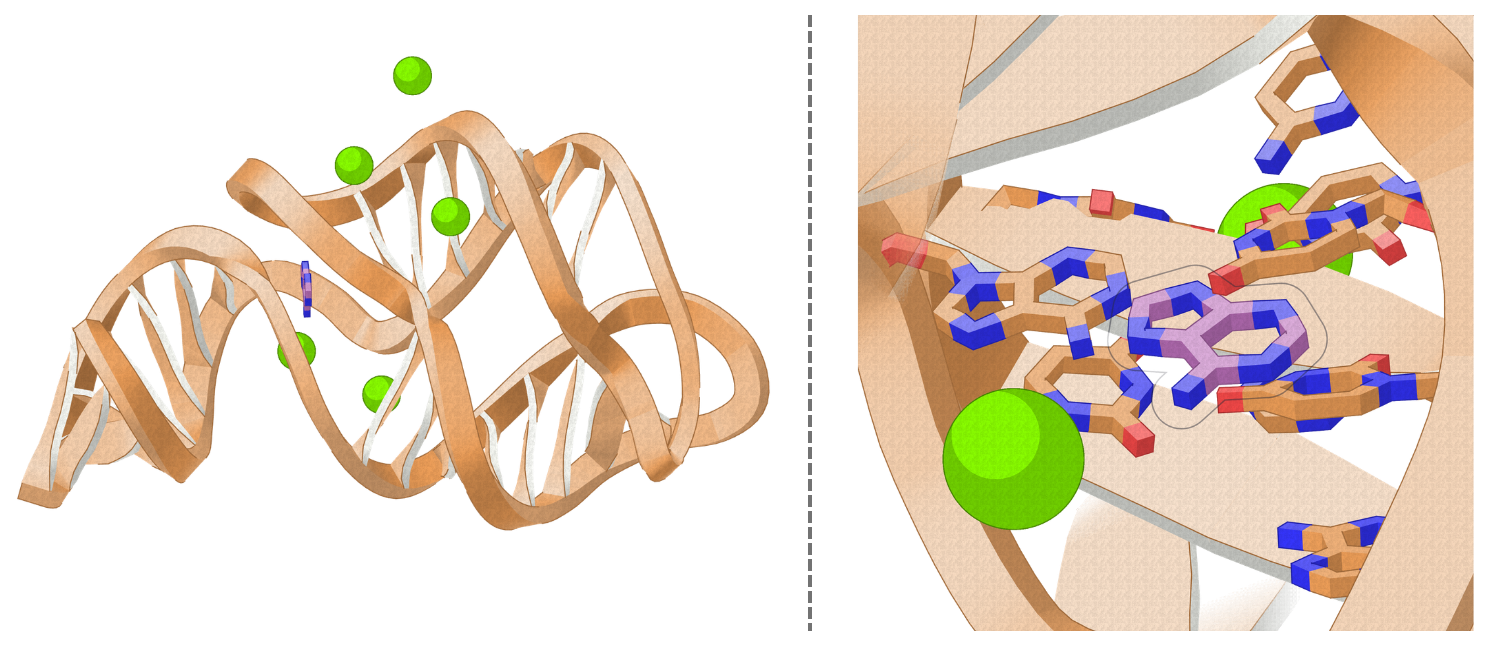

**El código es idéntico.** Lo único que cambia son dos campos de texto.

> ### Predicción
> El ligando es mucho más pequeño y tiene menos torsiones que el indinavir; el sitio
> está bien definido. **¿Esperan que funcione mejor o peor que con la proteína?**

In [ ]:
#@title C1 - Preparar y acoplar el sistema de RNA
PDB_RNA     = "1Y26"   #@param {type:"string"}
COD_LIG_RNA = "ADE"    #@param {type:"string"}
MARGEN_RNA  = 5.0      #@param {type:"number"}
EXH_RNA     = 8        #@param {type:"integer"}

n_rec2, n_lig2 = separar(PDB_RNA, COD_LIG_RNA)
xtal2, smiles2 = ligando_de_referencia(COD_LIG_RNA)
centro2, tam2 = caja_desde(xtal2, MARGEN_RNA)
rec2, n_at2 = preparar_receptor("receptor.pdb", "receptor_rna.pdbqt")
lig2, m2, n_tors2 = preparar_ligando(smiles2, 12345, "ligando_rna.pdbqt")

print("="*58)
print(f"  Átomos del receptor (RNA) : {n_at2}")
print(f"  SMILES del ligando        : {smiles2}")
print(f"  Caja: {tam2[0]:.0f} x {tam2[1]:.0f} x {tam2[2]:.0f} Å")
print("="*58)

poses2, ener2, dt2 = acoplar(rec2, lig2, centro2, tam2, EXH_RNA, 42, 9,
                             "poses_rna.pdbqt")
rmsd2, dk2 = evaluar(poses2, xtal2)
print(f"Docking terminado en {dt2:.0f} s")
mejor_C = tabla(ener2, rmsd2, f"{PDB_RNA} · riboswitch + {COD_LIG_RNA}")
ver_poses(dk2, xtal2, n=3)

In [ ]:
#@title C1b · Diagrama 2D de interacciones sobre el RNA
import warnings; warnings.filterwarnings("ignore")
import prolif as plf, MDAnalysis as mda
from prolif.plotting.network import LigNetwork
from IPython.display import display, HTML

QUE_POSE_RNA = "acoplada"   #@param ["acoplada", "cristal"]

_mejor2 = Chem.Mol(dk2); _mejor2.RemoveAllConformers()
_mejor2.AddConformer(dk2.GetConformer(0), assignId=True)
_mol = _mejor2 if QUE_POSE_RNA == "acoplada" else xtal2

_lig = plf.Molecule.from_rdkit(Chem.AddHs(_mol, addCoords=True))
# el receptor es RNA, no proteína: tomamos todos los átomos
_rec = plf.Molecule.from_mda(mda.Universe("receptor.pdb").atoms, NoImplicit=False)

fp2 = plf.Fingerprint()
fp2.run_from_iterable([_lig], _rec, progress=False)
tabla2 = fp2.to_dataframe().T

print(f"Pose: {QUE_POSE_RNA},  interacciones detectadas: {tabla2.shape[0]}\n")
print(tabla2.reset_index()[["protein", "interaction"]].to_string(index=False))

net2 = LigNetwork.from_fingerprint(fp2, _lig, kind="frame", frame=0)
net2.save("red_rna.html")
display(HTML(open("red_rna.html").read()))

In [ ]:
#@title C2 - Proteína contra RNA, lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(rmsds, energias, s=60, color=C_REC, edgecolors="k",
              linewidths=0.4, label=f"{PDB_ID} (proteína)")
ax[0].scatter(rmsd2, ener2, s=60, color=C_XTAL, edgecolors="k",
              linewidths=0.4, label=f"{PDB_RNA} (RNA)")
ax[0].axvline(2.0, ls="--", c="#b91c1c", lw=1.3)
ax[0].set_xlabel("RMSD (Å)"); ax[0].set_ylabel("afinidad (kcal/mol)")
ax[0].set_title("Mismo método, dos tipos de receptor")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.25)

ax[1].bar(["proteína\n(dirigida)", "proteína\n(a ciegas)", "RNA"],
          [mejor_A, mejor_B, mejor_C],
          color=[C_REC, GRIS, C_XTAL], alpha=0.9)
ax[1].axhline(2.0, ls="--", c="#b91c1c", lw=1.3)
ax[1].set_ylabel("mejor RMSD alcanzado (Å)")
ax[1].set_title("Resumen"); ax[1].grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()



Un número de -8 kcal/mol no significa lo mismo en los dos casos, y el programa
no tiene forma de avisarles.

**¿POR QUÉ EL RNA ES MÁS DIFÍCIL?**

La función de puntuación de Vina se calibró con complejos proteína-ligando del
PDBbind. Los sitios de unión en RNA son distintos:

- mucho más cargados y polares (un fosfato por nucleótido)
- el apilamiento entre bases pesa más que el efecto hidrofóbico
- la desolvatación se comporta de otra forma
- muchos sitios dependen de Mg2+
- el RNA es más flexible, y el docking trata al receptor como **RÍGIDO**


---

## Para llevarse

1. **Sin referencia, el docking siempre "funciona".** El redocking es el
   control mínimo antes de creerle a cualquier resultado.
2. **La importancia de la caja.** Centrarla en el sitio conocido funciona. En un proyecto real no conocen el sitio.
3. **El docking es estocástico.** Una corrida es una muestra. Corran réplicas.
4. **La puntuación ordena poses dentro de un sistema.** Unas pocas kcal/mol separan una pose perfecta de una equivocada.
5. **Docking predice POSES, no AFINIDADES.**
6. **Con RNA hay que ser más cuidadosos**, porque la función de puntuación no se calibró con ácidos nucleicos (en el caso de `VINA`). Eso no lo invalida, hay que validar más.
7. **El receptor es rígido.** En este eejercicio. Es posible darle felxibilidad al receptor.

---

### Preguntas

1. En la Parte A le dimos al programa el centro del sitio de unión, que sacamos de la estructura cristalográfica. Si no tuvieran esa estructura, ¿cómo elegirían la caja?

2. Supongan que acoplan diez ligandos a su proteína y los ordenan por puntuación. ¿Qué tan en serio se tomarían el orden? ¿Y las diferencias de 0.5 kcal/mol?

3. El receptor no se movió ni un Angstrom durante todo este ejercicio, ¿qué opinan de esa aproximación?